## Script for statistics of binary relevance prediction

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import utils

In [2]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../output/PI_DataSe_multilabel_results.csv"

nnrti_results_filepath_ml = "../output/NNRTI_DataSe_multilabel_results.csv"

nrti_results_filepath_ml = "../output/NRTI_DataSe_multilabel_results.csv"

ini_results_filepath_ml = "../output/INI_DataSe_multilabel_results.csv"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



In [3]:
file = "Binary_Relevance_MOC_prediction.csv"

models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs = {}



for path in filepath_list:
    acc_list = []
    for model in models:
        results = pd.read_csv(path + model + file)
        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels)

        acc_list.append(sub_acc)
    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})


print(sub_accs)

df_sub_accs = pd.DataFrame(sub_accs)


#plt.bar(df_sub_accs)

{'PI': [0.6578171091445427, 0.6283185840707964, 0.640117994100295, 0.6519174041297935], 'NNRTI': [0.6896551724137931, 0.5517241379310345, 0.5517241379310345, 0.5689655172413793], 'NRTI': [0.5732368896925859, 0.5479204339963833, 0.5623869801084991, 0.5515370705244123], 'INI': [0.6274509803921569, 0.5490196078431373, 0.5686274509803921, 0.6274509803921569]}


In [4]:

#df_sub_accs = pd.DataFrame(sub_accs)

print(df_sub_accs)
#plt.bar(df_sub_accs)

         PI     NNRTI      NRTI       INI
0  0.657817  0.689655  0.573237  0.627451
1  0.628319  0.551724  0.547920  0.549020
2  0.640118  0.551724  0.562387  0.568627
3  0.651917  0.568966  0.551537  0.627451


Axes(0.125,0.53;0.352273x0.35)
0
Axes(0.547727,0.53;0.352273x0.35)
1
Axes(0.125,0.11;0.352273x0.35)
2
Axes(0.547727,0.11;0.352273x0.35)
3


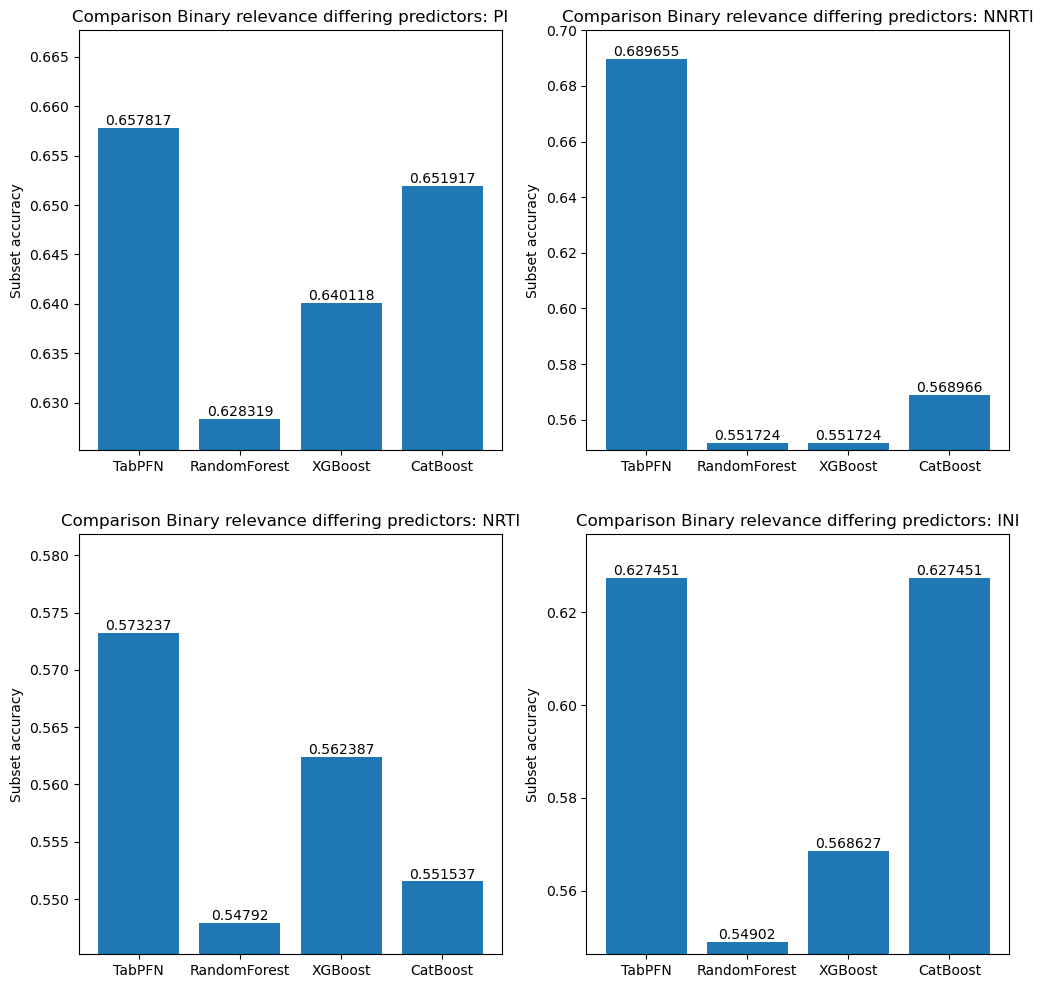

In [5]:
models_w_TabPFN = ["TabPFN", "RandomForest", "XGBoost", "CatBoost"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    print(axs[i])
    print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs[drug])

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, df_sub_accs[drug].min()* 0.995), min(1.0, df_sub_accs[drug].max()  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)




    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


In [6]:
file = "Binary_Relevance_5_fold_MOC_prediction.csv"

models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs = {}


path = filepath_list[3]
model = models[1]


results = pd.read_csv(path + model + file)

subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*")), include_groups=False)


print(subs_accs_groups)

#print(results.groupby(by="kFolds").agg(utils.subset_acc(results.filter(regex="Pred_*"), results.filter(regex="True_*"))))

"""
for path in filepath_list:
    acc_list = []
    for model in models:
        results = pd.read_csv(path + model + file)
        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels)

        acc_list.append(sub_acc)
    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})
"""

#print(sub_accs)

df_sub_accs = pd.DataFrame(sub_accs)


#plt.bar(df_sub_accs)

kFolds
0.0    0.387097
1.0    0.225806
2.0    0.193548
3.0    0.225806
4.0    0.333333
dtype: float64


In [7]:
print(results)

     Unnamed: 0  True_RAL  True_EVG  True_DTG  True_BIC  Pred_RAL  Pred_EVG  \
0             0       1.0       1.0       1.0       1.0       0.0       1.0   
1             1       0.0       0.0       0.0       0.0       0.0       0.0   
2             2       0.0       1.0       0.0       0.0       0.0       1.0   
3             3       0.0       0.0       0.0       0.0       0.0       0.0   
4             4       0.0       1.0       0.0       0.0       0.0       0.0   
..          ...       ...       ...       ...       ...       ...       ...   
149         149       1.0       1.0       0.0       0.0       0.0       0.0   
150         150       1.0       1.0       0.0       0.0       0.0       0.0   
151         151       1.0       1.0       1.0       1.0       1.0       1.0   
152         152       1.0       1.0       0.0       0.0       1.0       1.0   
153         153       0.0       0.0       0.0       0.0       0.0       0.0   

     Pred_DTG  Pred_BIC  kFolds  
0         0.0    